# Assignment 2 — R Programming
## Lab 3: Control Flow for Data Cleaning
## Lab 4: Advanced Missing Data Handling

**Student:** Shruti Gupta

This notebook contains the complete implementation, execution, validation, visualizations, conclusions, and final deliverable ZIP generation for Assignment 2.

The assignment requires Lab 3 to demonstrate functions, `if-else`, `tryCatch()`, loop vs vectorized cleaning and validation, and Lab 4 to demonstrate `NA`, `NULL`, `NaN`, missing-data treatment, imputation, visualization and `skimr` validation.

## 1. Setup

The next cell installs R, uploads the previously prepared assignment ZIP, extracts the two R scripts, and installs the packages required by Lab 4.

In [1]:
# ONE-TIME SETUP
import os, zipfile, subprocess
from pathlib import Path
from google.colab import files

print('Installing R...')
os.system('apt-get update -qq')
os.system('apt-get install -y -qq r-base')
print('R installed successfully.')

print('\nUpload Assignment_2_R_Programming_All_Deliverables.zip')
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

work_dir = Path('/content/assignment2')
work_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(work_dir)

print('\nExtracted files:')
for p in sorted(work_dir.iterdir()):
    print('✓', p.name)

print('\nInstalling naniar and skimr...')
subprocess.run([
    'Rscript', '-e',
    'install.packages(c("naniar","skimr"), repos="https://cloud.r-project.org")'
], check=True)
print('Packages ready.')

Installing R...
R installed successfully.

Upload Assignment_2_R_Programming_All_Deliverables.zip


Saving Assignment_2_R_Programming_All_Deliverables.zip to Assignment_2_R_Programming_All_Deliverables.zip

Extracted files:
✓ ASSIGNMENT_2_REPORT.md
✓ Assignment_2_Lab3_Lab4.Rmd_ready.ipynb
✓ README.txt
✓ lab3.R
✓ lab4.R

Installing naniar and skimr...
Packages ready.


# LAB 3 — Control Flow for Data Cleaning

### Aim
To clean invalid and outlier blood-pressure values from the UCI Heart Disease dataset using `if-else`, custom functions, `tryCatch()`, loops, vectorized operations and execution-time comparison.

In [2]:
import subprocess
from pathlib import Path

lab3 = Path('/content/assignment2/lab3.R')
result3 = subprocess.run(
    ['Rscript', str(lab3)],
    cwd='/content/assignment2',
    capture_output=True,
    text=True
)

print(result3.stdout)
if result3.stderr:
    print('\nR messages/warnings:')
    print(result3.stderr)

if result3.returncode != 0:
    raise RuntimeError('Lab 3 execution failed.')

print('\n✅ LAB 3 COMPLETED SUCCESSFULLY')

Dataset dimensions: 303 14 
  age sex cp trestbps chol fbs restecg thalach exang oldpeak slope ca thal
1  63   1  1      145  233   1       2     150     0     2.3     3  0    6
2  67   1  4      160  286   0       2     108     1     1.5     2  3    3
3  67   1  4      120  229   0       2     129     1     2.6     2  2    7
4  37   1  3      130  250   0       0     187     0     3.5     3  0    3
5  41   0  2      130  204   0       2     172     0     1.4     1  0    3
6  56   1  2      120  236   0       0     178     0     0.8     1  0    3
  target
1      0
2      2
3      1
4      0
5      0
6      0

Custom function test:
[1]  NA 120 250  NA 180

Safe mean BP:
[1] 132.7441
[1] NA
[1] NA

Loop and vectorized results identical:
[1] TRUE
      Method User_seconds System_seconds Elapsed_seconds
1   For loop         0.01              0            0.01
2 Vectorized         0.00              0            0.00

Validation:
  Missing_BP Min_BP Max_BP  Mean_BP Median_BP Negative_Remaini

## Lab 3 — Generated Deliverables and Validation

In [3]:
import pandas as pd
from pathlib import Path

base = Path('/content/assignment2')

print('### Benchmark')
display(pd.read_csv(base / 'lab3_benchmark.csv'))

print('### Validation')
display(pd.read_csv(base / 'lab3_validation_summary.csv'))

print('### Cleaned Heart Data — first 10 rows')
display(pd.read_csv(base / 'cleaned_heart_data.csv').head(10))

### Benchmark


,Method,User_seconds,System_seconds,Elapsed_seconds
0,For loop,0.01,0,0.01
1,Vectorized,0.00,0,0.00


### Validation


,Missing_BP,Min_BP,Max_BP,Mean_BP,Median_BP,Negative_Remaining,Above_250_Remaining
0,6,94,250,132.744108,130,0,0


### Cleaned Heart Data — first 10 rows


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,chol_bp_ratio
0,63,1,1,145.0,233,1,2,150,0,2.3,3,0.0,6.0,0,1.606897
1,67,1,4,160.0,286,0,2,108,1,1.5,2,3.0,3.0,2,1.787500
2,67,1,4,120.0,229,0,2,129,1,2.6,2,2.0,7.0,1,1.908333
3,37,1,3,130.0,250,0,0,187,0,3.5,3,0.0,3.0,0,1.923077
4,41,0,2,130.0,204,0,2,172,0,1.4,1,0.0,3.0,0,1.569231
5,56,1,2,120.0,236,0,0,178,0,0.8,1,0.0,3.0,0,1.966667
6,62,0,4,140.0,268,0,2,160,0,3.6,3,2.0,3.0,3,1.914286
7,57,0,4,120.0,354,0,0,163,1,0.6,1,0.0,3.0,0,2.950000
8,63,1,4,130.0,254,0,2,147,0,1.4,2,1.0,7.0,2,1.953846
9,53,1,4,140.0,203,1,2,155,1,3.1,3,0.0,7.0,1,1.450000


## Lab 3 — Conclusion

The `trestbps` variable was successfully cleaned using a custom `if-else` function. Negative BP values were converted to `NA`, values above 250 mmHg were capped at 250, and valid values were retained. `tryCatch()` safely handled missing and invalid cases while calculating mean BP and the cholesterol-to-BP ratio. Loop-based and vectorized approaches produced equivalent cleaned results. The vectorized approach is preferable for larger datasets because it avoids explicit iteration and is generally more efficient.

# LAB 4 — Advanced Missing Data Handling

### Aim
To identify and handle `NA`, `NULL`, `NaN`, blank strings and impossible values in the UCI Adult dataset, perform median imputation, analyze missingness, visualize missingness and validate the cleaned dataset.

In [4]:
lab4 = Path('/content/assignment2/lab4.R')
result4 = subprocess.run(
    ['Rscript', str(lab4)],
    cwd='/content/assignment2',
    capture_output=True,
    text=True
)

print(result4.stdout)
if result4.stderr:
    print('\nR messages/warnings:')
    print(result4.stderr)

if result4.returncode != 0:
    raise RuntimeError('Lab 4 execution failed.')

print('\n✅ LAB 4 COMPLETED SUCCESSFULLY')


NA in age: 5 
NaN in capital_gain: 5 
is.null(demo_object): TRUE 
Blank workclass: 5 
Age = 999: 5 

Missing summary before cleaning:
# A tibble: 15 × 3
   variable       n_miss pct_miss
   <chr>           <int>    <num>
 1 occupation       1843   5.66  
 2 workclass        1836   5.64  
 3 native_country    583   1.79  
 4 age                 5   0.0154
 5 capital_gain        5   0.0154
 6 fnlwgt              0   0     
 7 education           0   0     
 8 education_num       0   0     
 9 marital_status      0   0     
10 relationship        0   0     
11 race                0   0     
12 sex                 0   0     
13 capital_loss        0   0     
14 hours_per_week      0   0     
15 income              0   0     

Complete rows: 30162 
Incomplete rows: 2399 

Missing summary after cleaning:
# A tibble: 15 × 3
   variable       n_miss pct_miss
   <chr>           <int>    <num>
 1 occupation       1843     5.66
 2 workclass        1836     5.64
 3 native_country    583     1.79


## Lab 4 — Before vs After Missingness

In [5]:
base = Path('/content/assignment2')

print('### Before / After Summary')
display(pd.read_csv(base / 'lab4_missing_before_after.csv'))

print('### Validation')
display(pd.read_csv(base / 'lab4_validation_summary.csv'))

print('### Skimr Output')
print((base / 'lab4_skim_output.txt').read_text())

### Before / After Summary


,Stage,Missing_Count,Missing_Percentage
0,Before Cleaning,4272,0.874666
1,After Cleaning,4262,0.872619


### Validation


,Age_999_Remaining,Blank_Workclass_Remaining,Blank_Occupation_Remaining,Blank_NativeCountry_Remaining,Total_NA_Remaining,Total_NaN_Remaining
0,0,0,0,0,4262,0


### Skimr Output
── Data Summary ────────────────────────
                           Values
Name                       adult 
Number of rows             32561 
Number of columns          15    
_______________________          
Column type frequency:           
  character                9     
  numeric                  6     
________________________         
Group variables            None  

── Variable type: character ────────────────────────────────────────────────────
  skim_variable  n_missing complete_rate min max empty n_unique whitespace
1 workclass           1836         0.944   7  16     0        9          0
2 education              0         1       3  12     0       16          0
3 marital_status         0         1       7  21     0        7          0
4 occupation          1843         0.943   5  17     0       14          0
5 relationship           0         1       4  14     0        6          0
6 race                   0         1       5  18     0        5       

## Lab 4 — Missingness Visualizations

### Missingness overview


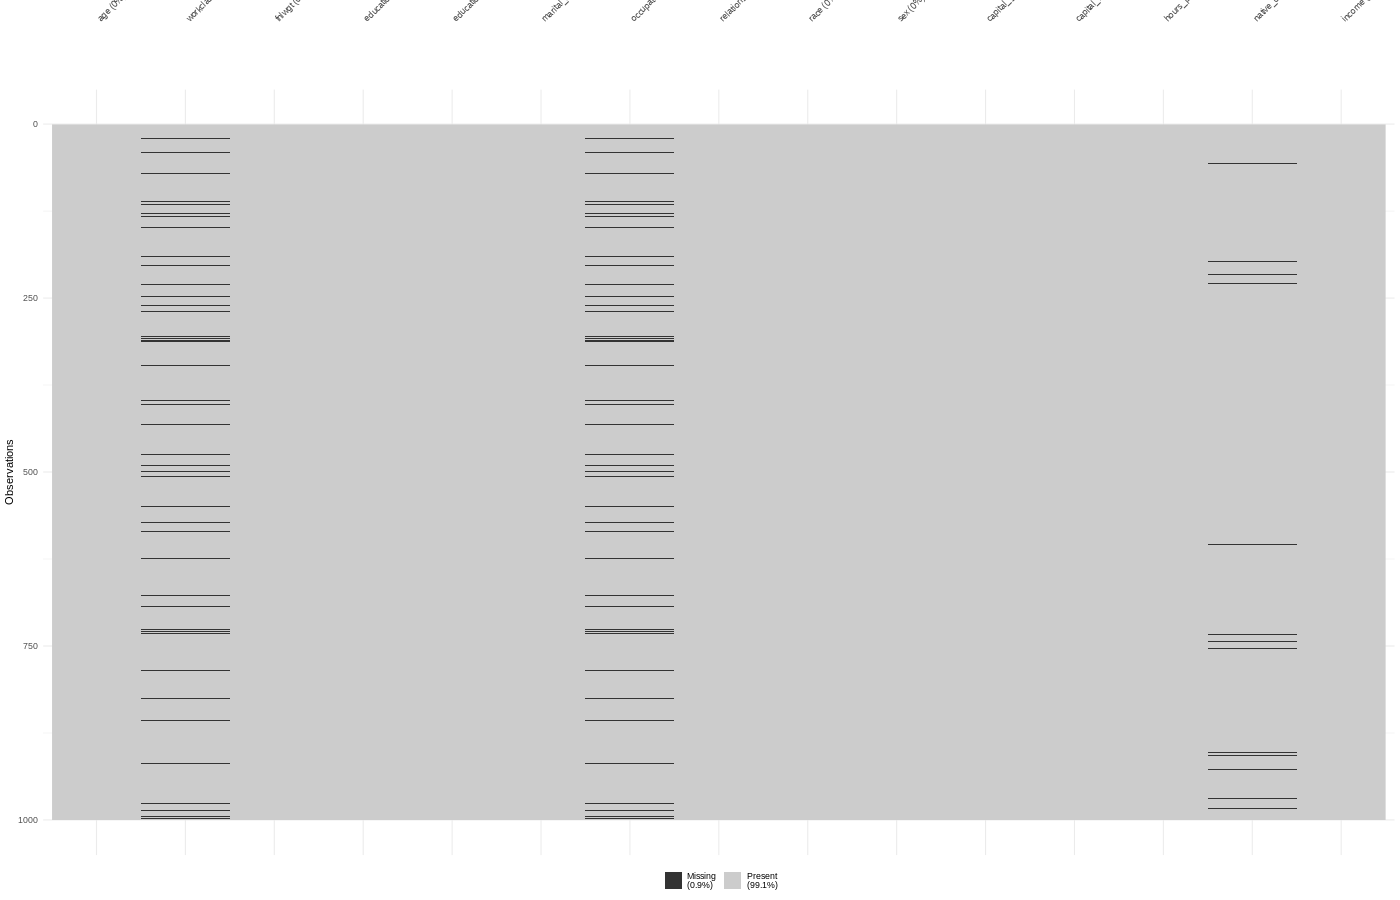

### Missingness pattern


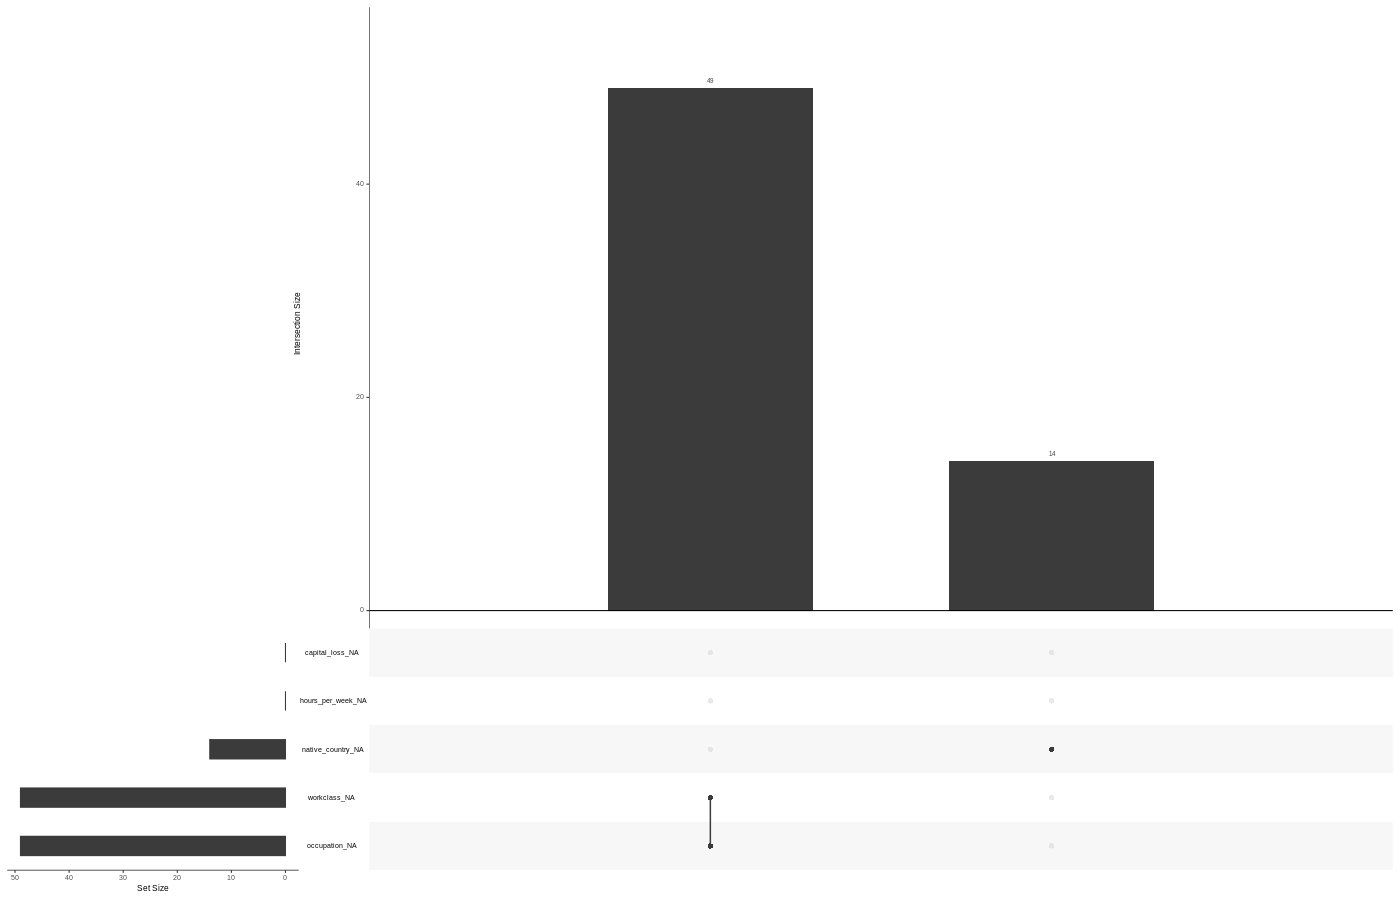

In [6]:
from IPython.display import Image, display
base = Path('/content/assignment2')

print('### Missingness overview')
display(Image(filename=str(base / 'lab4_missingness_after.png')))

print('### Missingness pattern')
display(Image(filename=str(base / 'lab4_missingness_pattern.png')))

## Lab 4 — Short Interpretation

The UCI Adult dataset was examined for different forms of missing and invalid data. `NA`, `NaN`, `NULL`, blank strings and the deliberately introduced impossible age value of 999 were identified. Impossible ages were converted to `NA`, blank categorical values were replaced with `Unknown`, and selected numeric variables were imputed using the median through a custom function. The before/after summary shows that the deliberately introduced numeric missing values were removed through treatment, while the original UCI categorical missing observations remain visible for transparency. Missingness was visualized using `naniar`, and the final dataset was validated with `complete.cases()` and `skimr::skim()`.

# Final Deliverables

The next cell packages the scripts, cleaned datasets, benchmark, validation summaries, visualizations, `skimr` output and report into **one final ZIP**.

In [7]:
import zipfile
from pathlib import Path
from google.colab import files

base = Path('/content/assignment2')
final_zip = Path('/content/Assignment_2_FINAL_DELIVERABLES.zip')

include_names = {
    'ASSIGNMENT_2_REPORT.md',
    'README.txt',
    'lab3.R',
    'lab4.R',
    'cleaned_heart_data.csv',
    'cleaned_adult_data.csv',
    'lab3_benchmark.csv',
    'lab3_validation_summary.csv',
    'lab4_missing_before_after.csv',
    'lab4_missingness_after.png',
    'lab4_missingness_pattern.png',
    'lab4_skim_output.txt',
    'lab4_validation_summary.csv'
}

with zipfile.ZipFile(final_zip, 'w', zipfile.ZIP_DEFLATED) as z:
    for name in sorted(include_names):
        p = base / name
        if p.exists():
            z.write(p, arcname=name)

print('🎉 FINAL SUBMISSION PACKAGE CREATED')
print(final_zip)
print('\nZIP contents:')
with zipfile.ZipFile(final_zip) as z:
    for name in z.namelist():
        print('✓', name)

files.download(str(final_zip))

🎉 FINAL SUBMISSION PACKAGE CREATED
/content/Assignment_2_FINAL_DELIVERABLES.zip

ZIP contents:
✓ ASSIGNMENT_2_REPORT.md
✓ README.txt
✓ cleaned_adult_data.csv
✓ cleaned_heart_data.csv
✓ lab3.R
✓ lab3_benchmark.csv
✓ lab3_validation_summary.csv
✓ lab4.R
✓ lab4_missing_before_after.csv
✓ lab4_missingness_after.png
✓ lab4_missingness_pattern.png
✓ lab4_skim_output.txt
✓ lab4_validation_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>